In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside Jupyter
%matplotlib inline

# Better looking graphs
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("cleaned_superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Order Year,Order Month,Order Day,Delivery Days
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2309.650,7,0.0,762.1845,933.57,Critical,2012,July,Tuesday,0
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,3709.395,9,0.1,-288.7650,923.63,Critical,2013,February,Tuesday,2
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,5175.171,9,0.1,919.9710,915.49,Medium,2013,October,Thursday,1
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,2892.510,5,0.1,-96.5400,910.16,Medium,2013,January,Monday,2
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,2832.960,8,0.0,311.5200,903.04,Critical,2013,November,Tuesday,1


In [4]:
df.shape

(51290, 27)

In [5]:
sales_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

sales_category

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64

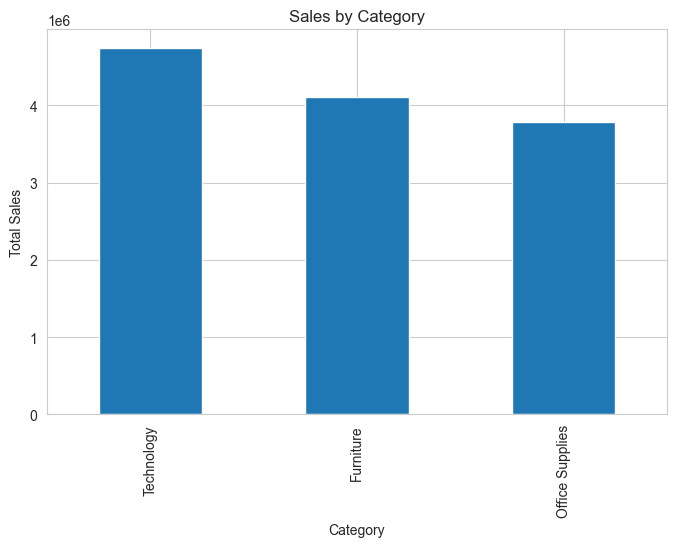

In [6]:
plt.figure(figsize=(8,5))

sales_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [7]:
profit_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

profit_category

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

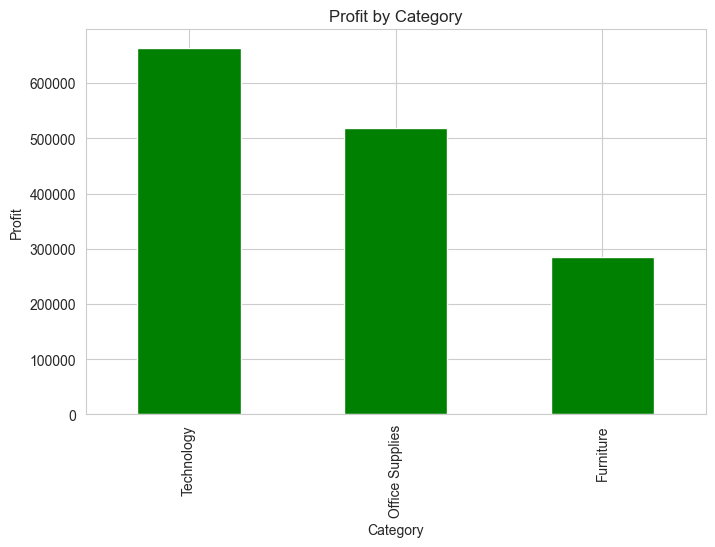

In [8]:
plt.figure(figsize=(8,5))

profit_category.plot(kind="bar", color="green")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [9]:
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sales_region

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64

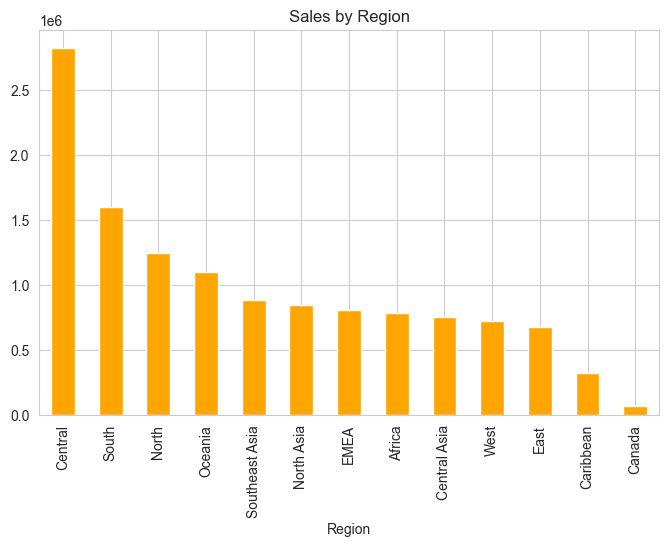

In [10]:
plt.figure(figsize=(8,5))

sales_region.plot(kind="bar", color="orange")

plt.title("Sales by Region")

plt.show()

In [11]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Bart Watters          32310.44650
Natalie Fritzler      31781.25850
Fred Hopkins          30400.67452
Jane Waco             30288.45030
Hunter Lopez          30243.56658
Name: Sales, dtype: float64

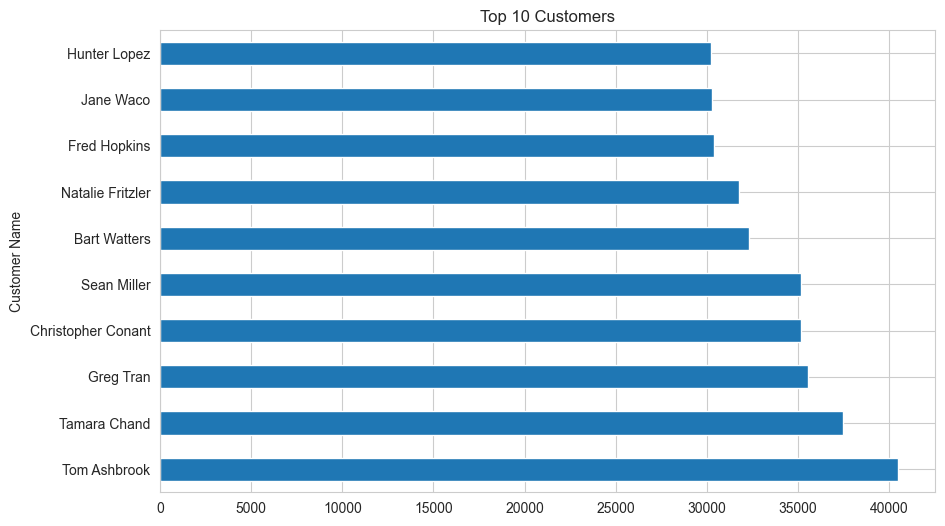

In [12]:
plt.figure(figsize=(10,6))

top_customers.plot(kind="barh")

plt.title("Top 10 Customers")

plt.show()

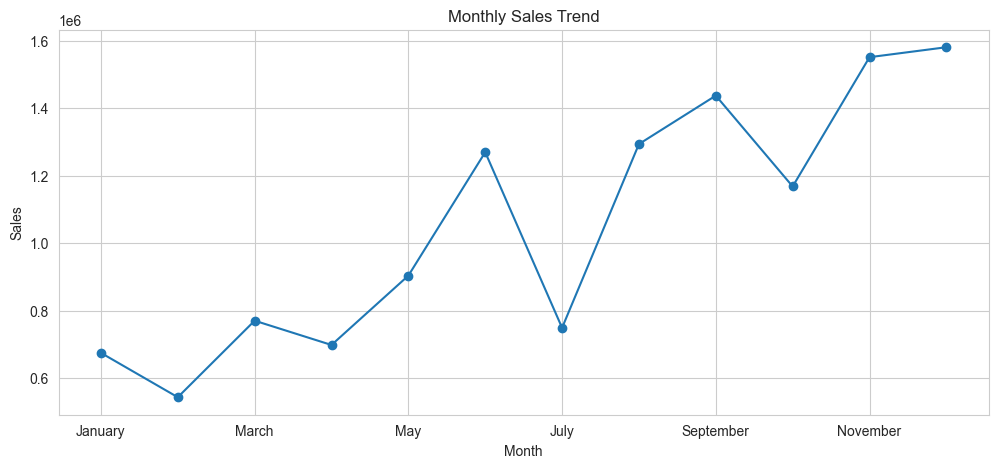

In [13]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

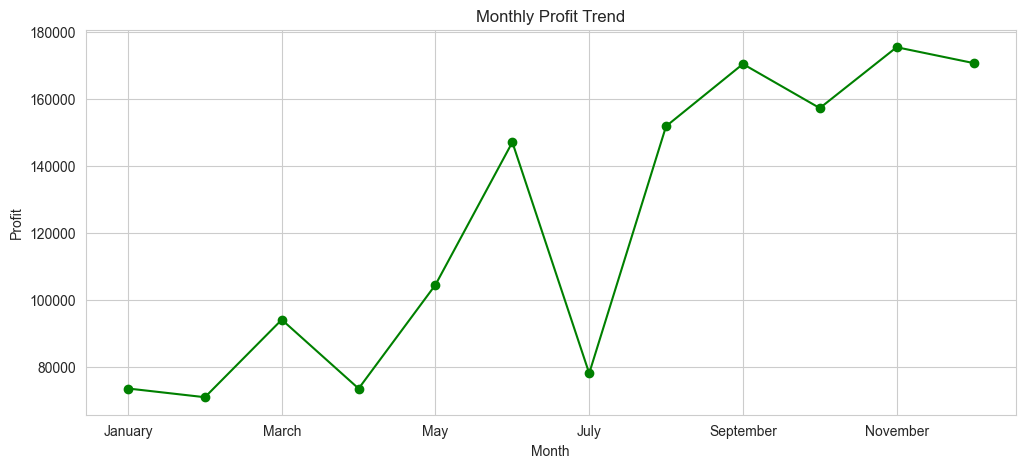

In [14]:
monthly_profit = df.groupby("Order Month")["Profit"].sum()

monthly_profit = monthly_profit.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_profit.plot(color="green", marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

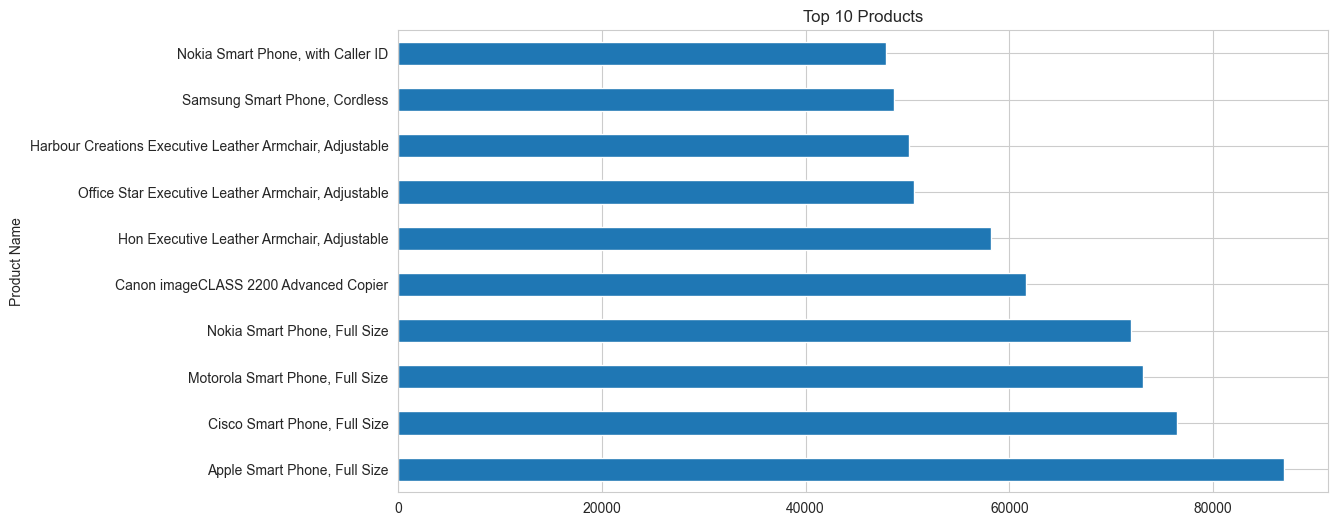

In [15]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.show()

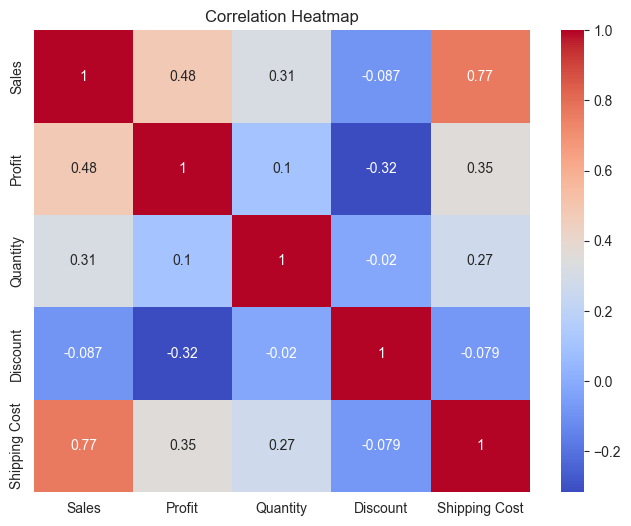

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales","Profit","Quantity","Discount","Shipping Cost"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

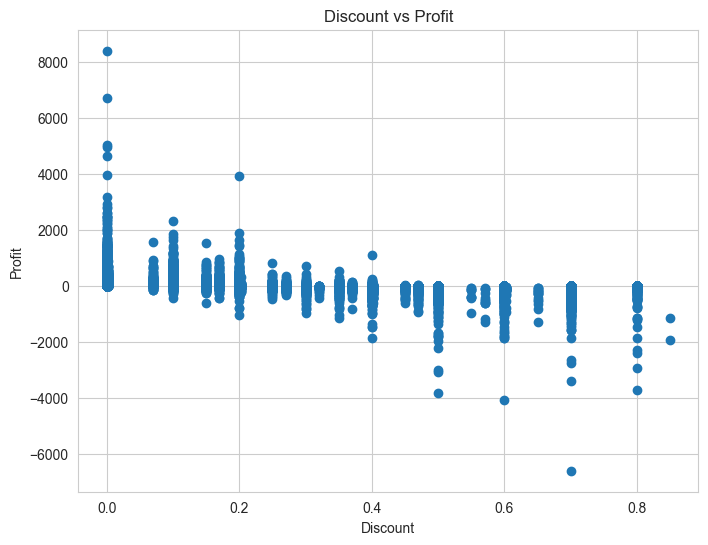

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()